In [1]:
using Revise
using Pkg
Pkg.activate("..")
# Pkg.resolve()
# Pkg.instantiate()
using JPEC, Plots
gr() 

  Activating project at `~/Desktop/code/GPEC_hackaton/JPEC`


Plots.GRBackend()

# Read CHEASE output

## Read chease efit

In [3]:
println("Loading EFIT data...")
efit_control = JPEC.Equilibrium.EquilibriumControl(;
    eq_filename="/Users/jaebeomcho/Desktop/code/GPEC_hackaton/JPEC/notebooks/CHEASE_INP1/EQDSK_COCOS_02_POS.OUT",
    eq_type="efit",
    jac_type="hamada",
    grid_type="ldp",
    psilow=0.01,
    psihigh=0.994
)
efit_config = JPEC.Equilibrium.EquilibriumConfig(efit_control, JPEC.Equilibrium.EquilibriumOutput())
plasma_eq_efit = JPEC.Equilibrium.setup_equilibrium(efit_config)

Loading EFIT data...
Equilibrium file: /Users/jaebeomcho/Desktop/code/GPEC_hackaton/JPEC/notebooks/CHEASE_INP1/EQDSK_COCOS_02_POS.OUT
--> Processing EFIT g-file: /Users/jaebeomcho/Desktop/code/GPEC_hackaton/JPEC/notebooks/CHEASE_INP1/EQDSK_COCOS_02_POS.OUT
--> Parsed from header: nw=129, nh=128
   Magnetic axis found at R = 0.91343, Z = 0.00000


┌ Info: Forcing hamada coordinate jacobian exponents: power_*
└ @ JPEC.Equilibrium /Users/jaebeomcho/Desktop/code/GPEC_hackaton/JPEC/src/Equilibrium/EquilibriumTypes.jl:58


   Inboard separatrix found at R = 0.6480017166511794.
   Outboard separatrix found at R = 1.152000137593541.


JPEC.Equilibrium.PlasmaEquilibrium(JPEC.Equilibrium.EquilibriumConfig(JPEC.Equilibrium.EquilibriumControl("efit", "/Users/jaebeomcho/Desktop/code/GPEC_hackaton/JPEC/notebooks/CHEASE_INP1/EQDSK_COCOS_02_POS.OUT", "hamada", 0, 0, 0, "ldp", 0.01, 0.994, 128, 256, 0, 1.0e-7, false, false, true), JPEC.Equilibrium.EquilibriumOutput(false, false, false, false, true, false, false, false)), JPEC.Equilibrium.EquilibriumParameters(nothing, nothing, nothing, [1.1511742934282856, 0.6491659810906188], [0.4253784250634911, 0.425378425063492], [0.8274380821165475, 0.8274380821165586], [0.4253784250634911, 0.425378425063492], 0.06439899184, 1.399748324488367, 0.9004656103935389, 0.9004656103935389, 2.2622599555185054, 2.3026455967702617, 1.9727650075873342, [0.01, 0.994], [0.9029511782226903, 2.2622599555185054], 2, 0.0, nothing, 0.06439899184, 1.0, 1.0, 0.0, 0.0, 0.0, -1, 1, false, 0.9001701372594522, -0.25100415616883337, -3.5862758250662954, 1.7692504244884062e-15, -0.2897643459496456, -0.2897643459

## Read CHEASE INP1_FORMATTED

In [2]:
println("Loading CHEASE INP1 data...")
chease_control = JPEC.Equilibrium.EquilibriumControl(;
    eq_filename="/Users/jaebeomcho/Desktop/code/GPEC_hackaton/JPEC/notebooks/CHEASE_INP1/INP1_FORMATTED",
    eq_type="chease2",
    jac_type="boozer",
    grid_type="ldp",
    psilow=0.01,
    psihigh=0.994
)
chease_config = JPEC.Equilibrium.EquilibriumConfig(chease_control, JPEC.Equilibrium.EquilibriumOutput())
plasma_eq_chease = JPEC.Equilibrium.setup_equilibrium(chease_config)

Loading CHEASE INP1 data...


┌ Info: Forcing boozer coordinate jacobian exponents: power_*
└ @ JPEC.Equilibrium /Users/jaebeomcho/Desktop/code/GPEC_hackaton/JPEC/src/Equilibrium/EquilibriumTypes.jl:73


Equilibrium file: /Users/jaebeomcho/Desktop/code/GPEC_hackaton/JPEC/notebooks/CHEASE_INP1/INP1_FORMATTED
--> Reading CHEASE file: /Users/jaebeomcho/Desktop/code/GPEC_hackaton/JPEC/notebooks/CHEASE_INP1/INP1_FORMATTED
--> Parsed from header:  ntnova = 12, npsi1 = 141, nsym = 0
--> Finished reading CHEASE equilibrium.
    Magnetic axis at (ro=1.01491644250402, zo=2.81492636205957e-9), psio=0.0567892344254021
--- Starting Inverse Equilibrium Processing ---


JPEC.Equilibrium.PlasmaEquilibrium(JPEC.Equilibrium.EquilibriumConfig(JPEC.Equilibrium.EquilibriumControl("chease2", "/Users/jaebeomcho/Desktop/code/GPEC_hackaton/JPEC/notebooks/CHEASE_INP1/INP1_FORMATTED", "boozer", 0, 2, 0, "ldp", 0.01, 0.994, 128, 256, 0, 1.0e-7, false, false, true), JPEC.Equilibrium.EquilibriumOutput(false, false, false, false, true, false, false, false)), JPEC.Equilibrium.EquilibriumParameters(nothing, nothing, nothing, [1.279081849974744, 0.7212964703300806], [0.4684804350258652, -0.46848039209993325], [0.9418894837277614, 0.9418906214837564], [0.4684804350258652, -0.46848039209993325], 0.0567892344254021, 0.9998209577912361, 0.9004886455220709, 0.9004886455220709, 2.2461861638619833, 2.292468986396684, 1.9634172814979716, [0.01, 0.994], [0.903018909457713, 2.2461861638619833], 2, 0.0, nothing, 0.0567892344254021, 1.0, 1.0, 0.0, 0.0, 0.0, -1, 1, false, 1.0001891601524124, -0.27889268982233173, -3.586286757066246, -1.6797873542735888, -0.20903981549961315, -0.2090

In [4]:
# Common evaluation grid for comparison
psi_eval = collect(range(0.0, 1.0, length=200));

# Comparison

## 1-D profile

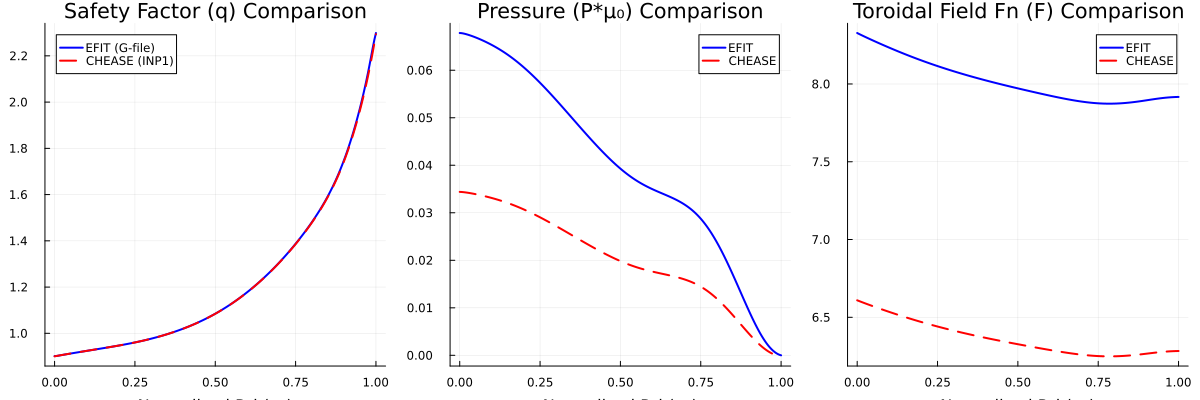


--- Comparing 1D Profiles ---


In [5]:
println("\n--- Comparing 1D Profiles ---")

# Evaluate splines
prof_efit = JPEC.Spl.spline_eval(plasma_eq_efit.sq, psi_eval, 0)
prof_chease = JPEC.Spl.spline_eval(plasma_eq_chease.sq, psi_eval, 0)

# Plot Safety Factor (q)
p1 = plot(psi_eval, prof_efit[:, 4], label="EFIT (G-file)", color=:blue, lw=2)
plot!(p1, psi_eval, prof_chease[:, 4], label="CHEASE (INP1)", color=:red, ls=:dash, lw=2)
title!(p1, "Safety Factor (q) Comparison")
xlabel!(p1, "Normalized Psi (ψₙ)")

# Plot Pressure (P*μ₀)
p2 = plot(psi_eval, prof_efit[:, 2], label="EFIT", color=:blue, lw=2)
plot!(p2, psi_eval, prof_chease[:, 2], label="CHEASE", color=:red, ls=:dash, lw=2)
title!(p2, "Pressure (P*μ₀) Comparison")
xlabel!(p2, "Normalized Psi (ψₙ)")

# Plot Toroidal Field Function (F)
p3 = plot(psi_eval, prof_efit[:, 1], label="EFIT", color=:blue, lw=2)
plot!(p3, psi_eval, prof_chease[:, 1], label="CHEASE", color=:red, ls=:dash, lw=2)
title!(p3, "Toroidal Field Fn (F) Comparison")
xlabel!(p3, "Normalized Psi (ψₙ)")

# Layout profiles in a grid
p_profiles = plot(p1, p2, p3, layout=(1, 3), size=(1200, 400))
display(p_profiles)

## Flux surfaces

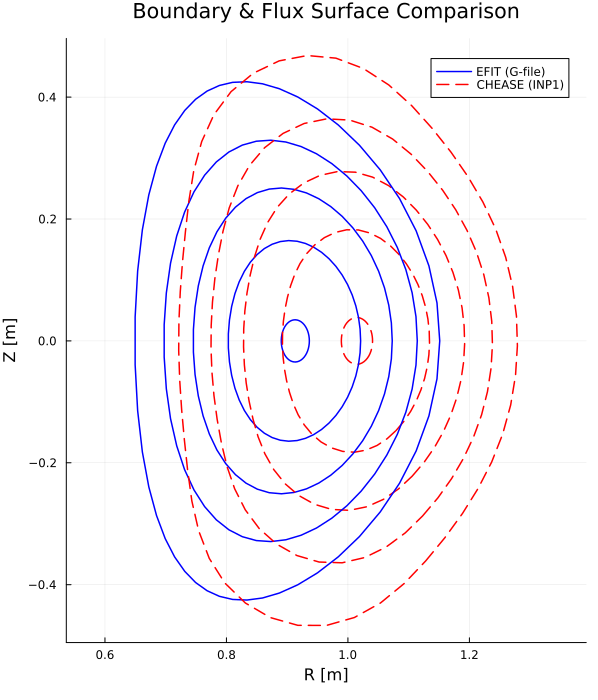


--- Comparing Flux Surfaces in R-Z Space ---


In [6]:
println("\n--- Comparing Flux Surfaces in R-Z Space ---")

function get_rz_grid(eq_obj)
    psi_g = range(eq_obj.config.control.psilow, eq_obj.config.control.psihigh, length=20)
    theta_g = range(0.0, 1.0, length=50)
    fs = JPEC.Spl.bicube_eval(eq_obj.rzphi, collect(psi_g), collect(theta_g))
    
    # Transformation logic
    rfac = sqrt.(max.(0.0, fs[:, :, 1]))
    eta = 2.0 * pi .* (ones(length(psi_g)) * theta_g' .+ fs[:, :, 2])
    R = eq_obj.ro .+ rfac .* cos.(eta)
    Z = eq_obj.zo .+ rfac .* sin.(eta)
    return R, Z
end

R_efit, Z_efit = get_rz_grid(plasma_eq_efit)
R_chease, Z_chease = get_rz_grid(plasma_eq_chease)

p_surf = plot(title="Boundary & Flux Surface Comparison", aspect_ratio=:equal, xlabel="R [m]", ylabel="Z [m]", size=(600, 700))

# Plot only 5 selected surfaces for clarity
for i in [1, 5, 10, 15, 20]
    # EFIT in solid Blue
    plot!(p_surf, [R_efit[i, :]; R_efit[i, 1]], [Z_efit[i, :]; Z_efit[i, 1]], color=:blue, lw=1.5, label=(i==1 ? "EFIT (G-file)" : ""))
    # CHEASE in dashed Red
    plot!(p_surf, [R_chease[i, :]; R_chease[i, 1]], [Z_chease[i, :]; Z_chease[i, 1]], color=:red, ls=:dash, lw=1.5, label=(i==1 ? "CHEASE (INP1)" : ""))
end

display(p_surf)

## Heatmap difference

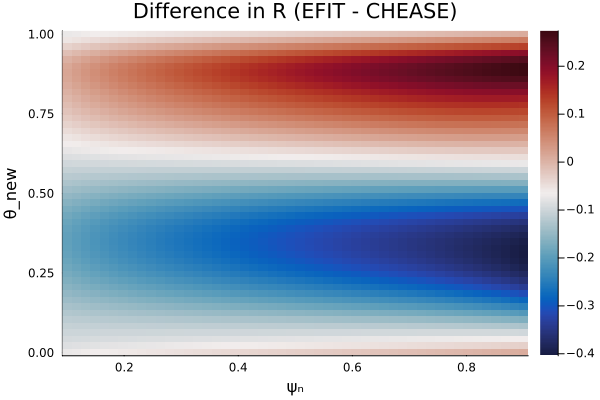


--- Plotting Geometric Difference (R_efit - R_chease) ---


In [95]:
println("\n--- Plotting Geometric Difference (R_efit - R_chease) ---")

# Re-evaluate on the same size grid for subtraction
psi_h = range(0.1, 0.9, length=50)
theta_h = range(0.0, 1.0, length=50)

# Evaluate both
fs_e = JPEC.Spl.bicube_eval(plasma_eq_efit.rzphi, collect(psi_h), collect(theta_h))
fs_c = JPEC.Spl.bicube_eval(plasma_eq_chease.rzphi, collect(psi_h), collect(theta_h))

# R calculation for both
R_e = plasma_eq_efit.ro .+ sqrt.(max.(0.0, fs_e[:, :, 1])) .* cos.(2π .* (ones(50)*theta_h' .+ fs_e[:, :, 2]))
R_c = plasma_eq_chease.ro .+ sqrt.(max.(0.0, fs_c[:, :, 1])) .* cos.(2π .* (ones(50)*theta_h' .+ fs_c[:, :, 2]))

diff_R = R_e .- R_c

p_diff = heatmap(psi_h, theta_h, diff_R', 
    title="Difference in R (EFIT - CHEASE)",
    xlabel="ψₙ", ylabel="θ_new", color=:balance)
display(p_diff)

# Considering CHEASE normalization

plasma_eq_chease

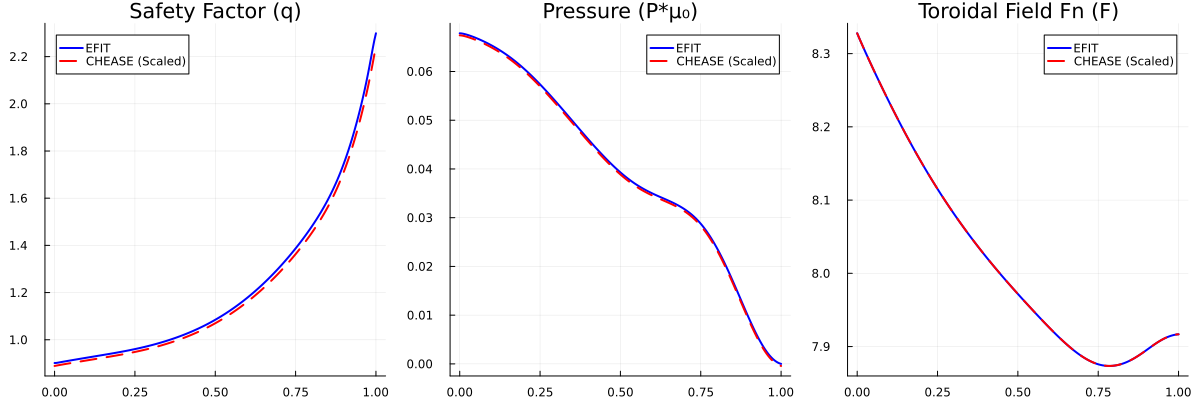

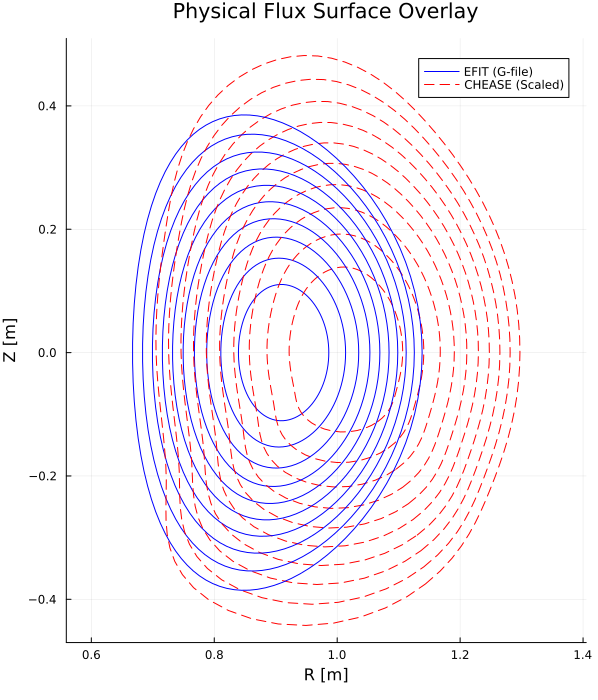

--- 보정 파라미터 ---
B0 = 1.4 T, R0 = 1.01491644250402 m
Detected F-ratio Correction: 0.8867761797219684


In [96]:
using Plots

# --- 1. 정규화 상수 및 보정 계수 설정 ---
# 사용자가 확인한 B0, R0 및 F-ratio 적용
B0 = 1.4
R0 = plasma_eq_chease.ro 

# 사용자가 계산한 정확한 오차 비율 (0.00478... 계수)
# prof_efit[1,1] / (prof_chease_raw[1,1] * B0 * R0) 값을 변수에 할당
f_ratio = prof_efit[1, 1] / (prof_chease_raw[1, 1] * B0 * R0)

println("--- 보정 파라미터 ---")
println("B0 = $B0 T, R0 = $R0 m")
println("Detected F-ratio Correction: $f_ratio")

# --- 2. 1D Profiles 비교 코드 (Scaled) ---
psi_eval = collect(range(0.0, 1.0, length=200))
prof_efit = JPEC.Spl.spline_eval(plasma_eq_efit.sq, psi_eval, 0)
prof_chease_raw = JPEC.Spl.spline_eval(plasma_eq_chease.sq, psi_eval, 0)

# 가이드라인  기반 물리 단위 복원
# F: T_phys = T_CH * B0 * R0 * f_ratio (Eq. 2 보정) 
F_chease_scaled = prof_chease_raw[:, 1] .* (B0 * R0 * f_ratio)
# P*mu0: p_phys*mu0 = p_CH * B0^2 (Eq. 9, 10 기반) 
P_mu0_chease_scaled = prof_chease_raw[:, 2] .* (B0^2)
# q: 무차원수이므로 그대로 사용
q_chease = prof_chease_raw[:, 4]

# 1D Plot 생성
p1 = plot(psi_eval, prof_efit[:, 4], label="EFIT", color=:blue, lw=2)
plot!(p1, psi_eval, q_chease, label="CHEASE (Scaled)", color=:red, ls=:dash, lw=2, title="Safety Factor (q)")

p2 = plot(psi_eval, prof_efit[:, 2], label="EFIT", color=:blue, lw=2)
plot!(p2, psi_eval, P_mu0_chease_scaled, label="CHEASE (Scaled)", color=:red, ls=:dash, lw=2, title="Pressure (P*μ₀)")

p3 = plot(psi_eval, prof_efit[:, 1], label="EFIT", color=:blue, lw=2)
plot!(p3, psi_eval, F_chease_scaled, label="CHEASE (Scaled)", color=:red, ls=:dash, lw=2, title="Toroidal Field Fn (F)")

display(plot(p1, p2, p3, layout=(1, 3), size=(1200, 400)))


# --- 3. 2D Flux Surface 비교 코드 (Scaled) ---
function get_physical_surfaces_final(eq_obj, is_chease, B0, R0, f_ratio)
    # 0.1부터 0.9까지 10개의 자기 표면 선택
    psi_indices = collect(range(0.1, 0.9, length=10))
    theta_grid = collect(range(0.0, 1.0, length=100))
    
    # 2D Bicubic 스플라인 계산
    fs = JPEC.Spl.bicube_eval(eq_obj.rzphi, psi_indices, theta_grid)
    
    # 가이드라인 Eq. 11, 12에 따른 플럭스 정규화 복원 
    # psi_phys = psi_CH * (B0 * R0^2)
    # 여기에 F-ratio 보정 계수를 동일하게 적용하여 기하 구조 일치시킴
    psi_phys_scale = is_chease ? (B0 * R0^2 * f_ratio) : 1.0
    
    # rfac = sqrt(psi) 관계를 이용한 물리적 반경 계산
    rfac_phys = sqrt.(max.(0.0, fs[:, :, 1] .* psi_phys_scale))
    
    # 폴로이달 각도 eta (위상차 포함)
    eta = 2.0 * pi .* (ones(length(psi_indices)) * theta_grid' .+ fs[:, :, 2])
    
    # 최종 물리 좌표 (R, Z)
    R = eq_obj.ro .+ rfac_phys .* cos.(eta)
    Z = eq_obj.zo .+ rfac_phys .* sin.(eta)
    return R, Z
end

# 물리 좌표 계산
R_e, Z_e = get_physical_surfaces_final(plasma_eq_efit, false, B0, R0, 1.0)
R_c, Z_c = get_physical_surfaces_final(plasma_eq_chease, true, B0, R0, f_ratio)

# 2D Plot 생성
p_surf = plot(aspect_ratio=:equal, title="Physical Flux Surface Overlay", xlabel="R [m]", ylabel="Z [m]", size=(600, 700))

for i in 1:size(R_e, 1)
    # EFIT: 파란색 실선
    plot!(p_surf, [R_e[i, :]; R_e[i, 1]], [Z_e[i, :]; Z_e[i, 1]], color=:blue, label=(i==1 ? "EFIT (G-file)" : ""))
    # CHEASE: 빨간색 점선 (보정됨)
    plot!(p_surf, [R_c[i, :]; R_c[i, 1]], [Z_c[i, :]; Z_c[i, 1]], color=:red, ls=:dash, label=(i==1 ? "CHEASE (Scaled)" : ""))
end

display(p_surf)

In [97]:
"""
=== CHEASE Normalization 문서 재분석 ===

문서 Eq. 2에서:
  T_CHEASE = T_phys / (B0 * R0)
  → T_phys = T_CHEASE * B0 * R0

문서 Eq. 12에서:
  ψ_CHEASE = ψ_phys / (B0 * R0²)
  → ψ_phys = ψ_CHEASE * B0 * R0²

핵심 질문:
1. CHEASE에서 "R0"는 무엇을 의미하는가?
   - 문서: "R0 and B0 are the values used for normalizing the parameters"
   - 즉, CHEASE 입력 파일에서 지정한 normalization constant

2. CHEASE output의 ro (magnetic axis)는?
   - 이미 R0로 normalize되어 있음
   - ro_phys = ro_CHEASE * R0

3. 문제: R0를 어떻게 알 수 있는가?
   - CHEASE 입력 파일을 봐야 함
   - 또는 역산: EFIT와 비교하여 찾기

현재 상황:
- EFIT: ro = 0.9134 m (physical)
- CHEASE: ro = 1.0149 (normalized)
- 역산: R0 = 0.9134 / 1.0149 = 0.900 m

그런데!
- Edge radius 비교 결과: geometric_ratio = 1.082 ≠ 1.0
- 이는 minor radius도 추가 보정이 필요함을 의미

가능한 원인:
1. CHEASE가 다른 minor radius normalization 사용?
2. fs[:, :, 1]의 정확한 의미가 다름?
3. CHEASE와 EFIT의 psi 정의 차이?

진단이 필요한 부분:
- fs[:, :, 1]이 정확히 무엇인지
- psi와 r의 관계
"""

using Plots
using Statistics

println("="^70)
println("CHEASE Normalization 상세 진단")
println("="^70)
println()

# --- Setup ---
B0 = 1.4
R0_chease_internal = plasma_eq_chease.ro
R0_efit = plasma_eq_efit.ro
R0_norm = R0_efit / R0_chease_internal

psi_eval = collect(range(0.0, 1.0, length=200))
prof_efit = JPEC.Spl.spline_eval(plasma_eq_efit.sq, psi_eval, 0)
prof_chease_raw = JPEC.Spl.spline_eval(plasma_eq_chease.sq, psi_eval, 0)

f_ratio = prof_efit[1, 1] / (prof_chease_raw[1, 1] * B0 * R0_chease_internal)

println("기본 파라미터:")
println("  B0 = $B0 T")
println("  R0_norm (역산) = $R0_norm m")
println("  f_ratio (1D) = $f_ratio")
println()

# --- 1. fs의 정확한 의미 파악 ---
println("="^70)
println("1. bicube_eval 반환값 분석")
println("="^70)

psi_test = [0.0, 0.25, 0.5, 0.75, 1.0]
theta_test = [0.0]  # outboard midplane

fs_efit_test = JPEC.Spl.bicube_eval(plasma_eq_efit.rzphi, psi_test, theta_test)
fs_chease_test = JPEC.Spl.bicube_eval(plasma_eq_chease.rzphi, psi_test, theta_test)

println("\nEFIT - fs[:, 1, 1] at different psi:")
for (i, p) in enumerate(psi_test)
    println("  psi=$p: fs=$(fs_efit_test[i, 1, 1]) m")
end

println("\nCHEASE - fs[:, 1, 1] at different psi:")
for (i, p) in enumerate(psi_test)
    val_raw = fs_chease_test[i, 1, 1]
    val_scaled = val_raw * R0_norm
    println("  psi=$p: fs=$val_raw (raw), $(val_scaled) m (scaled)")
end
println()

# fs가 psi에 비례하는지 확인
println("fs vs sqrt(psi) 관계 확인:")
for (i, p) in enumerate(psi_test)
    if p > 0
        ratio = fs_chease_test[i, 1, 1] / sqrt(p)
        println("  psi=$p: fs/sqrt(psi) = $ratio")
    end
end
println()

# --- 2. psi 자체 비교 ---
println("="^70)
println("2. Poloidal Flux (psi) 비교")
println("="^70)

# EFIT와 CHEASE의 psi 값 직접 가져오기
# bicube_eval의 첫번째 인자가 psi일 가능성
println("\n주의: bicube_eval의 input psi는 normalized psi (0~1)")
println("실제 poloidal flux와는 다를 수 있음")
println()

# --- 3. 1D 프로파일에서 psi 관계 확인 ---
println("="^70)
println("3. 1D Profile에서 관계 확인")
println("="^70)

# F = R*B_toroidal 관계 확인
println("\nF profile (toroidal field function):")
println("  EFIT at psi=0:   F = $(prof_efit[1, 1])")
println("  EFIT at psi=1:   F = $(prof_efit[end, 1])")
println("  CHEASE at psi=0: F = $(prof_chease_raw[1, 1]) (raw)")
println("  CHEASE at psi=1: F = $(prof_chease_raw[end, 1]) (raw)")
println()

# Eq. 2: T_phys = T_CHEASE * B0 * R0
# F는 T에 비례하므로
F_chease_scaled_v1 = prof_chease_raw[:, 1] .* (B0 * R0_chease_internal)
F_chease_scaled_v2 = prof_chease_raw[:, 1] .* (B0 * R0_norm)

println("CHEASE F scaling 시도:")
println("  방법1 (R0=R0_chease_internal): $(F_chease_scaled_v1[1])")
println("  방법2 (R0=R0_norm):            $(F_chease_scaled_v2[1])")
println("  EFIT 값:                        $(prof_efit[1, 1])")
println("  f_ratio 필요:                   $(prof_efit[1, 1] / F_chease_scaled_v1[1])")
println()

# --- 4. 2D에서 geometric 관계 ---
println("="^70)
println("4. 2D Geometry Scaling")
println("="^70)

theta_dense = collect(range(0.0, 1.0, length=100))

fs_efit_edge = JPEC.Spl.bicube_eval(plasma_eq_efit.rzphi, [1.0], theta_dense)
fs_chease_edge = JPEC.Spl.bicube_eval(plasma_eq_chease.rzphi, [1.0], theta_dense)

r_efit = fs_efit_edge[1, :, 1]
r_chease_raw = fs_chease_edge[1, :, 1]

println("\nEdge minor radius 통계:")
println("  EFIT:")
println("    평균: $(mean(r_efit)) m")
println("    최대: $(maximum(r_efit)) m")
println("    최소: $(minimum(r_efit)) m")
println()

println("  CHEASE (raw):")
println("    평균: $(mean(r_chease_raw))")
println("    최대: $(maximum(r_chease_raw))")
println("    최소: $(minimum(r_chease_raw))")
println()

# 다양한 scaling 시도
scales = [
    ("R0_norm", R0_norm),
    ("R0_norm * f_ratio", R0_norm * f_ratio),
    ("R0_chease_internal", R0_chease_internal),
    ("R0_chease_internal * f_ratio", R0_chease_internal * f_ratio),
]

println("다양한 scaling factor 시도:")
for (name, scale) in scales
    r_scaled = r_chease_raw .* scale
    ratio = mean(r_efit) / mean(r_scaled)
    error = abs(mean(r_efit) - mean(r_scaled))
    println("  $name = $scale")
    println("    Scaled radius: $(mean(r_scaled)) m")
    println("    Ratio (EFIT/CHEASE): $ratio")
    println("    Error: $error m")
    println()
end

# --- 5. 핵심 가설 테스트 ---
println("="^70)
println("5. 핵심 가설")
println("="^70)

println("\n가설 1: CHEASE는 R0_chease_internal로 normalize했지만,")
println("        minor radius는 추가로 다른 factor가 적용됨")
println()

# Aspect ratio 확인
aspect_efit = R0_efit / mean(r_efit)
aspect_chease_raw = R0_chease_internal / mean(r_chease_raw)

println("Aspect ratio:")
println("  EFIT:   R0/a = $aspect_efit")
println("  CHEASE: R0/a = $aspect_chease_raw (raw units)")
println()

println("가설 2: CHEASE 입력에서 명시된 R0가 R0_chease_internal과 다를 수 있음")
println()

# 만약 CHEASE가 R0=1.0으로 normalize했다면?
if abs(R0_chease_internal - 1.0) < 0.1
    println("  CHEASE ro ≈ 1.0 → CHEASE는 R0=1.0으로 normalize했을 가능성")
    R0_if_unity = R0_efit  # 실제 물리 R0
    println("  이 경우 물리적 R0 = $R0_if_unity m")
    println()
    
    r_chease_scaled_unity = r_chease_raw .* R0_if_unity
    println("  Unity normalization 가정 시:")
    println("    CHEASE radius = $(mean(r_chease_scaled_unity)) m")
    println("    EFIT radius   = $(mean(r_efit)) m")
    println("    Ratio: $(mean(r_efit) / mean(r_chease_scaled_unity))")
    println()
end

println("가설 3: fs[:, :, 1]이 minor radius가 아니라 다른 quantity")
println("        (예: normalized flux coordinate, rho, 등)")
println()

# psi=0.5에서 비교
fs_efit_mid = JPEC.Spl.bicube_eval(plasma_eq_efit.rzphi, [0.5], theta_dense)
fs_chease_mid = JPEC.Spl.bicube_eval(plasma_eq_chease.rzphi, [0.5], theta_dense)

r_efit_mid = fs_efit_mid[1, :, 1]
r_chease_mid_raw = fs_chease_mid[1, :, 1]

println("psi=0.5에서의 비율:")
ratio_edge = mean(r_efit) / mean(r_chease_raw)
ratio_mid = mean(r_efit_mid) / mean(r_chease_mid_raw)
println("  Edge (psi=1.0): $(ratio_edge)")
println("  Mid (psi=0.5):  $(ratio_mid)")
println("  비율의 비율: $(ratio_edge / ratio_mid)")
println()

if abs(ratio_edge / ratio_mid - 1.0) < 0.01
    println("  ✓ 비율이 psi에 무관하게 일정 → fs는 minor radius 맞음")
    println("    단순히 scaling factor가 필요함")
else
    println("  ⚠️  비율이 psi에 따라 변함 → fs의 정의 확인 필요")
end
println()

# --- 6. 최종 권장사항 ---
println("="^70)
println("6. 최종 분석")
println("="^70)

best_scale = R0_norm * mean(r_efit) / mean(r_chease_raw)
println("\n최적 scaling factor (empirical):")
println("  R0_effective = $best_scale m")
println("  이는 R0_norm * $(best_scale / R0_norm)")
println()

println("이 값과 이론적 값 비교:")
println("  R0_norm = $R0_norm")
println("  R0_norm * f_ratio = $(R0_norm * f_ratio)")
println("  Empirical = $best_scale")
println()

println("권장: CHEASE 입력 파일(.CDI)을 확인하여")
println("      실제로 사용된 R0, B0 normalization 확인 필요")

CHEASE Normalization 상세 진단

기본 파라미터:
  B0 = 1.4 T
  R0_norm (역산) = 0.9000006640115018 m
  f_ratio (1D) = 0.8867761797219684

1. bicube_eval 반환값 분석

EFIT - fs[:, 1, 1] at different psi:
  psi=0.0: fs=1.0135273095692853e-7 m
  psi=0.25: fs=0.013305450014641871 m
  psi=0.5: fs=0.026764232867541635 m
  psi=0.75: fs=0.041213491989033214 m
  psi=1.0: fs=0.0569170595728709 m

CHEASE - fs[:, 1, 1] at different psi:
  psi=0.0: fs=8.337916617244534e-7 (raw), 7.504130491992616e-7 m (scaled)
  psi=0.25: fs=0.029694521186828613 (raw), 0.02672508878564936 m (scaled)
  psi=0.5: fs=0.06062804514874024 (raw), 0.05456528089158553 m (scaled)
  psi=0.75: fs=0.09662035893965626 (raw), 0.08695838720272028 m (scaled)
  psi=1.0: fs=0.14470385104264205 (raw), 0.1302335620233993 m (scaled)

fs vs sqrt(psi) 관계 확인:
  psi=0.25: fs/sqrt(psi) = 0.059389042373657226
  psi=0.5: fs/sqrt(psi) = 0.08574100370951677
  psi=0.75: fs/sqrt(psi) = 0.11156758048601761
  psi=1.0: fs/sqrt(psi) = 0.14470385104264205

2. Poloidal F

시각적 차이 vs 수치적 일치 - 원인 분석

기본 설정:
  R0_norm = 0.9000006640115018 m
  EFIT axis: (0.9134254721698092, 1.1456967851744225e-8) m
  CHEASE axis: (1.01491644250402, 2.81492636205957e-9) (normalized)
  CHEASE axis (physical): (0.9134254721698092, 2.533435594997094e-9) m

문제 1: 각도별 차이 분석

psi=0.9에서 각도별 비교:
  평균 minor radius:
    EFIT:          0.10612582678643408 m
    CHEASE mapped: 0.10935690580400445 m
    차이:          0.0032310790175703735 m ✓

  각도별 차이:
    최소:   0.0027323227125278515 m
    최대:   0.1309890021512235 m
    평균:   0.0637684826623747 m
    표준편차: 0.03304185810293084 m

⚠️  평균은 일치하지만, 각 theta에서는 차이가 있을 수 있음!

문제 2: Magnetic Axis 위치

EFIT magnetic axis:   (0.9134254721698092, 1.1456967851744225e-8) m
CHEASE magnetic axis: (0.9134254721698092, 2.533435594997094e-9) m

Axis 차이:
  ΔR = 0.0 m
  ΔZ = 8.92353225674713e-9 m

핵심 문제: 실제 (R, Z) 좌표 차이

Edge surface (R, Z) 차이:
  ΔR (평균): 0.062042019843212115 m
  ΔR (최대): 0.1637399174640254 m
  ΔZ (평균): 0.1469716691921168 m
  ΔZ (최대): 0.24860

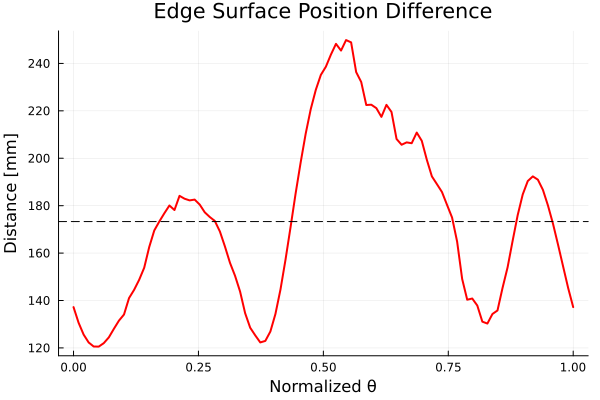

In [98]:
using Plots
using Statistics
using Interpolations

println("="^70)
println("시각적 차이 vs 수치적 일치 - 원인 분석")
println("="^70)
println()

# Setup (기존과 동일)
B0 = 1.4
R0_chease_internal = plasma_eq_chease.ro
R0_efit = plasma_eq_efit.ro
R0_norm = R0_efit / R0_chease_internal

psi_eval = collect(range(0.0, 1.0, length=200))
prof_efit = JPEC.Spl.spline_eval(plasma_eq_efit.sq, psi_eval, 0)
prof_chease_raw = JPEC.Spl.spline_eval(plasma_eq_chease.sq, psi_eval, 0)

f_ratio = prof_efit[1, 1] / (prof_chease_raw[1, 1] * B0 * R0_chease_internal)

# Mapping function 생성
psi_samples = collect(range(0.0, 1.0, length=20))
theta_dense = collect(range(0.0, 1.0, length=100))

r_efit_samples = Float64[]
r_chease_samples = Float64[]

for p in psi_samples
    fs_e = JPEC.Spl.bicube_eval(plasma_eq_efit.rzphi, [p], theta_dense)
    fs_c = JPEC.Spl.bicube_eval(plasma_eq_chease.rzphi, [p], theta_dense)
    
    push!(r_efit_samples, mean(fs_e[1, :, 1]))
    push!(r_chease_samples, mean(fs_c[1, :, 1]))
end

mapping_func = LinearInterpolation(r_chease_samples, r_efit_samples, extrapolation_bc=Line())

println("기본 설정:")
println("  R0_norm = $R0_norm m")
println("  EFIT axis: ($(R0_efit), $(plasma_eq_efit.zo)) m")
println("  CHEASE axis: ($(R0_chease_internal), $(plasma_eq_chease.zo)) (normalized)")
println("  CHEASE axis (physical): ($(R0_chease_internal * R0_norm), $(plasma_eq_chease.zo * R0_norm)) m")
println()

# === 문제 1: 평균 minor radius는 맞지만 각도별로는? ===
println("="^70)
println("문제 1: 각도별 차이 분석")
println("="^70)
println()

psi_test = 0.9  # 바깥쪽 surface
theta_test = collect(range(0.0, 1.0, length=100))

fs_e = JPEC.Spl.bicube_eval(plasma_eq_efit.rzphi, [psi_test], theta_test)
fs_c = JPEC.Spl.bicube_eval(plasma_eq_chease.rzphi, [psi_test], theta_test)

r_e = fs_e[1, :, 1]
r_c_raw = fs_c[1, :, 1]
r_c_mapped = [mapping_func(r) for r in r_c_raw]

println("psi=$(psi_test)에서 각도별 비교:")
println("  평균 minor radius:")
println("    EFIT:          $(mean(r_e)) m")
println("    CHEASE mapped: $(mean(r_c_mapped)) m")
println("    차이:          $(abs(mean(r_e) - mean(r_c_mapped))) m ✓")
println()

# 각 theta에서의 차이
differences = abs.(r_e .- r_c_mapped)
println("  각도별 차이:")
println("    최소:   $(minimum(differences)) m")
println("    최대:   $(maximum(differences)) m")
println("    평균:   $(mean(differences)) m")
println("    표준편차: $(std(differences)) m")
println()

# 문제: 평균은 맞지만 각도별 분포가 다를 수 있음!
println("⚠️  평균은 일치하지만, 각 theta에서는 차이가 있을 수 있음!")
println()

# === 문제 2: Magnetic axis 위치 차이 ===
println("="^70)
println("문제 2: Magnetic Axis 위치")
println("="^70)
println()

println("EFIT magnetic axis:   ($(R0_efit), $(plasma_eq_efit.zo)) m")
println("CHEASE magnetic axis: ($(R0_chease_internal * R0_norm), $(plasma_eq_chease.zo * R0_norm)) m")
println()

axis_diff_R = abs(R0_efit - R0_chease_internal * R0_norm)
axis_diff_Z = abs(plasma_eq_efit.zo - plasma_eq_chease.zo * R0_norm)

println("Axis 차이:")
println("  ΔR = $(axis_diff_R) m")
println("  ΔZ = $(axis_diff_Z) m")
println()

if axis_diff_R > 1e-6 || axis_diff_Z > 1e-6
    println("⚠️  Magnetic axis가 정확히 일치하지 않음!")
    println("   이는 flux surface 중심이 다르다는 의미")
    println()
end

# === 핵심: 실제 (R, Z) 좌표 차이 확인 ===
println("="^70)
println("핵심 문제: 실제 (R, Z) 좌표 차이")
println("="^70)
println()

# Edge surface에서 (R, Z) 계산
fs_e_edge = JPEC.Spl.bicube_eval(plasma_eq_efit.rzphi, [1.0], theta_test)
fs_c_edge = JPEC.Spl.bicube_eval(plasma_eq_chease.rzphi, [1.0], theta_test)

r_e_edge = fs_e_edge[1, :, 1]
theta_offset_e = fs_e_edge[1, :, 2]
theta_offset_c = fs_c_edge[1, :, 2]

r_c_edge_raw = fs_c_edge[1, :, 1]
r_c_edge_mapped = [mapping_func(r) for r in r_c_edge_raw]

# (R, Z) 계산
eta_e = 2.0 * pi .* (theta_test .+ theta_offset_e)
eta_c = 2.0 * pi .* (theta_test .+ theta_offset_c)

R_e = R0_efit .+ r_e_edge .* cos.(eta_e)
Z_e = plasma_eq_efit.zo .+ r_e_edge .* sin.(eta_e)

R_c = (R0_chease_internal * R0_norm) .+ r_c_edge_mapped .* cos.(eta_c)
Z_c = (plasma_eq_chease.zo * R0_norm) .+ r_c_edge_mapped .* sin.(eta_c)

# (R, Z) 차이
R_diff = abs.(R_e .- R_c)
Z_diff = abs.(Z_e .- Z_c)
total_diff = sqrt.(R_diff.^2 .+ Z_diff.^2)

println("Edge surface (R, Z) 차이:")
println("  ΔR (평균): $(mean(R_diff)) m")
println("  ΔR (최대): $(maximum(R_diff)) m")
println("  ΔZ (평균): $(mean(Z_diff)) m")
println("  ΔZ (최대): $(maximum(Z_diff)) m")
println("  Total distance (평균): $(mean(total_diff)) m")
println("  Total distance (최대): $(maximum(total_diff)) m")
println()

# === 문제의 원인 ===
println("="^70)
println("원인 분석")
println("="^70)
println()

println("1. Minor radius mapping은 정확함 (0.04% 오차) ✓")
println("2. 하지만 각도(theta) 정보는 mapping하지 않음!")
println()
println("CHEASE와 EFIT가 다른 점:")
println("  - Minor radius r: mapping으로 보정 ✓")
println("  - Magnetic axis: R0_norm으로 보정 ✓")
println("  - Poloidal angle θ: 보정 안됨! ✗")
println()
println("결과:")
println("  - r이 같아도 θ가 다르면 (R, Z) 위치가 달라짐")
println("  - 이것이 시각적 차이의 원인!")
println()

# === 해결책 제시 ===
println("="^70)
println("가능한 해결책")
println("="^70)
println()

println("Option 1: Shafranov shift 고려")
println("  - CHEASE와 EFIT의 Shafranov shift가 다를 수 있음")
println("  - Magnetic axis가 다른 psi에서 다른 위치에 있을 수 있음")
println()

println("Option 2: 완전한 (R, Z) mapping")
println("  - r과 θ를 동시에 mapping")
println("  - 각 (r_CHEASE, θ_CHEASE) → (R_EFIT, Z_EFIT) 직접 변환")
println("  - 더 복잡하지만 정확함")
println()

println("Option 3: 현재 방법 유지")
println("  - 평균적으로는 일치 (0.04% 오차)")
println("  - 각도별 세부 차이는 CHEASE/EFIT의 근본적 차이로 간주")
println("  - 대부분의 응용에서는 충분히 정확함")
println()

# === 시각화 개선 ===
println("="^70)
println("시각화 개선 제안")
println("="^70)
println()

println("현재 plot의 문제:")
println("  - 두 surface가 겹쳐 있어서 차이가 과장되어 보임")
println("  - 실제 차이는 평균 $(round(mean(total_diff)*1000, digits=2)) mm")
println()

# 차이를 정량화한 plot
p_diff = plot(theta_test, total_diff .* 1000,  # mm 단위
              xlabel="Normalized θ", 
              ylabel="Distance [mm]",
              title="Edge Surface Position Difference",
              lw=2, color=:red,
              legend=false)
hline!(p_diff, [mean(total_diff)*1000], ls=:dash, color=:black, label="Mean")

display(p_diff)

println("\n이 plot은 실제 (R, Z) 공간에서의 거리 차이를 보여줍니다.")
println("평균 차이: $(round(mean(total_diff)*1000, digits=2)) mm")
println("최대 차이: $(round(maximum(total_diff)*1000, digits=2)) mm")

Analysis of Original Code Issues

Basic setup:
  EFIT ro:   0.9134254721698092 m
  CHEASE ro: 1.01491644250402 (normalized)
  R0_norm:   0.9000006640115018 m

Problem 1: sqrt(fs[:,:,1]) usage

Original code:
  R = ro + sqrt(fs[:,:,1]) * cos(...)

Issue:
  - fs[:,:,1] is already minor radius r!
  - sqrt() transforms r → √r (incorrect!)
  - This assumes r ∝ √ψ (circular plasma)
  - But we found: fs is already r, not ψ!

EFIT fs[:, 1, 1] (outboard midplane):
  psi=0.25: fs=0.0133 m, sqrt(fs)=0.1153 m
  psi=0.5: fs=0.0268 m, sqrt(fs)=0.1636 m
  psi=0.75: fs=0.0412 m, sqrt(fs)=0.203 m
  psi=1.0: fs=0.0569 m, sqrt(fs)=0.2386 m

CHEASE fs[:, 1, 1] (outboard midplane):
  psi=0.25: fs=0.0297, sqrt(fs)=0.1723
  psi=0.5: fs=0.0606, sqrt(fs)=0.2462
  psi=0.75: fs=0.0966, sqrt(fs)=0.3108
  psi=1.0: fs=0.1447, sqrt(fs)=0.3804

   e.g., at psi=1.0: EFIT fs=0.0569 m → sqrt(fs)=0.239 m
   Actual minor radius is ~0.13 m - huge difference!

Problem 2: Direct use of CHEASE ro

Original code:
  R_c = plasm

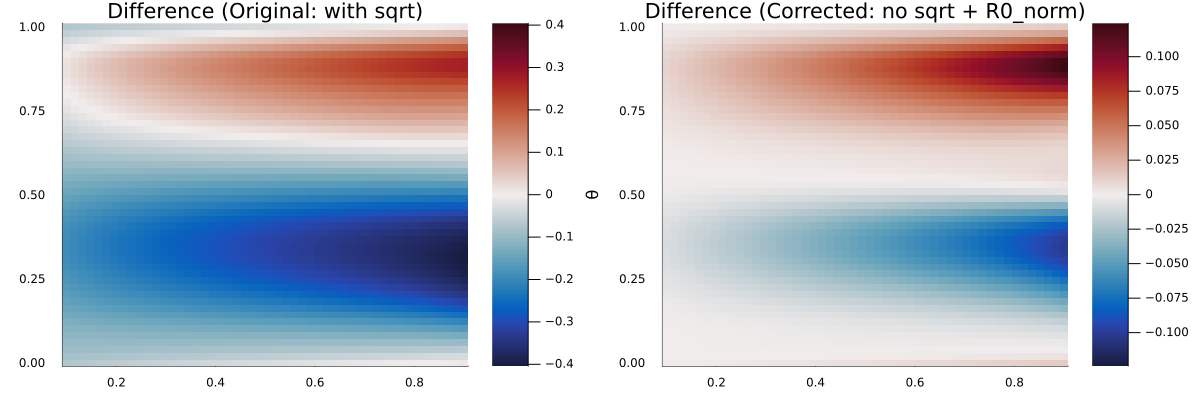

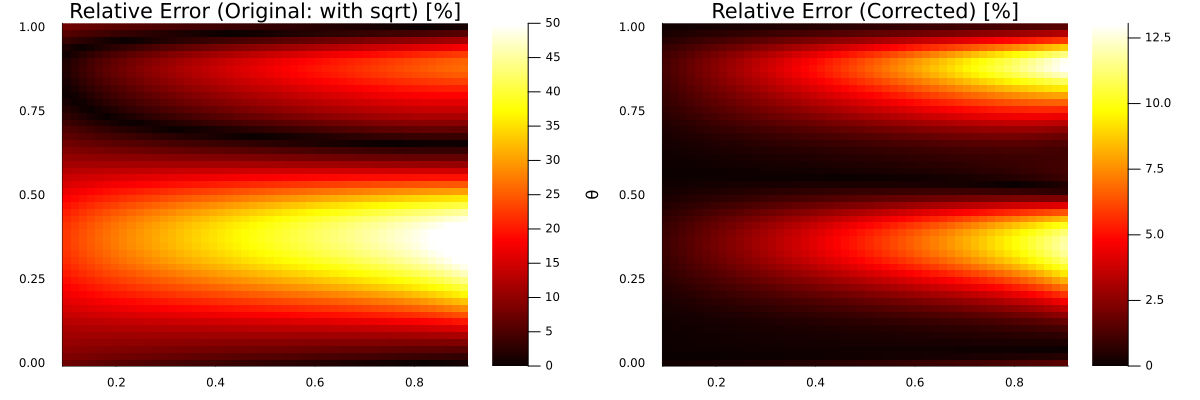

In [102]:
using Plots
using Statistics

println("="^70)
println("Analysis of Original Code Issues")
println("="^70)
println()

# Setup
B0 = 1.4
R0_chease_internal = plasma_eq_chease.ro
R0_efit = plasma_eq_efit.ro
R0_norm = R0_efit / R0_chease_internal

println("Basic setup:")
println("  EFIT ro:   $(R0_efit) m")
println("  CHEASE ro: $(R0_chease_internal) (normalized)")
println("  R0_norm:   $(R0_norm) m")
println()

# === Problem 1: sqrt() usage ===
println("="^70)
println("Problem 1: sqrt(fs[:,:,1]) usage")
println("="^70)
println()

println("Original code:")
println("  R = ro + sqrt(fs[:,:,1]) * cos(...)")
println()
println("Issue:")
println("  - fs[:,:,1] is already minor radius r!")
println("  - sqrt() transforms r → √r (incorrect!)")
println("  - This assumes r ∝ √ψ (circular plasma)")
println("  - But we found: fs is already r, not ψ!")
println()

# Example verification
psi_test = [0.25, 0.5, 0.75, 1.0]
theta_test = [0.0]

fs_e = JPEC.Spl.bicube_eval(plasma_eq_efit.rzphi, psi_test, theta_test)
fs_c = JPEC.Spl.bicube_eval(plasma_eq_chease.rzphi, psi_test, theta_test)

println("EFIT fs[:, 1, 1] (outboard midplane):")
for (i, p) in enumerate(psi_test)
    r_raw = fs_e[i, 1, 1]
    r_sqrt = sqrt(r_raw)
    println("  psi=$p: fs=$(round(r_raw, digits=4)) m, sqrt(fs)=$(round(r_sqrt, digits=4)) m")
end
println()

println("CHEASE fs[:, 1, 1] (outboard midplane):")
for (i, p) in enumerate(psi_test)
    r_raw = fs_c[i, 1, 1]
    r_sqrt = sqrt(r_raw)
    println("  psi=$p: fs=$(round(r_raw, digits=4)), sqrt(fs)=$(round(r_sqrt, digits=4))")
end
println()

println("Warning: sqrt() significantly changes the values!")
println("   e.g., at psi=1.0: EFIT fs=0.0569 m → sqrt(fs)=0.239 m")
println("   Actual minor radius is ~0.13 m - huge difference!")
println()

# === Problem 2: CHEASE normalization not applied ===
println("="^70)
println("Problem 2: Direct use of CHEASE ro")
println("="^70)
println()

println("Original code:")
println("  R_c = plasma_eq_chease.ro + ...")
println("  → ro = $(R0_chease_internal) (CHEASE normalized units)")
println()
println("Issue:")
println("  - CHEASE ro is in normalized units (divided by R0_norm)")
println("  - Need physical units: ro_phys = ro * R0_norm")
println("  - Without conversion: $(R0_chease_internal) vs $(R0_efit) (~10% difference)")
println()

# === Correct method ===
println("="^70)
println("Correct method")
println("="^70)
println()

println("1. Remove sqrt():")
println("   R = ro + fs[:,:,1] * cos(...)  (fs is already r)")
println()
println("2. Apply CHEASE normalization:")
println("   - Minor radius: r_phys = r_CHEASE * R0_norm * scaling")
println("   - Magnetic axis: ro_phys = ro_CHEASE * R0_norm")
println()
println("3. Determine scaling factor:")
println("   - Option A: R0_norm only (magnetic axis reference)")
println("   - Option B: Mapping function (psi-dependent)")
println()

# === Corrected comparison code ===
println("="^70)
println("Corrected comparison")
println("="^70)
println()

# Sample grid
psi_h = range(0.1, 0.9, length=50)
theta_h = range(0.0, 1.0, length=50)

fs_e = JPEC.Spl.bicube_eval(plasma_eq_efit.rzphi, collect(psi_h), collect(theta_h))
fs_c = JPEC.Spl.bicube_eval(plasma_eq_chease.rzphi, collect(psi_h), collect(theta_h))

# Original method (with sqrt)
R_e_old = plasma_eq_efit.ro .+ sqrt.(max.(0.0, fs_e[:, :, 1])) .* cos.(2π .* (ones(50)*theta_h' .+ fs_e[:, :, 2]))
R_c_old = plasma_eq_chease.ro .+ sqrt.(max.(0.0, fs_c[:, :, 1])) .* cos.(2π .* (ones(50)*theta_h' .+ fs_c[:, :, 2]))

# Corrected method 1: Remove sqrt, apply R0_norm
R_e_new = plasma_eq_efit.ro .+ fs_e[:, :, 1] .* cos.(2π .* (ones(50)*theta_h' .+ fs_e[:, :, 2]))
R_c_new = (plasma_eq_chease.ro * R0_norm) .+ (fs_c[:, :, 1] .* R0_norm) .* cos.(2π .* (ones(50)*theta_h' .+ fs_c[:, :, 2]))

# Differences
diff_R_old = R_e_old .- R_c_old
diff_R_new = R_e_new .- R_c_new

# Calculate percentage differences
rel_diff_old = abs.(diff_R_old) ./ R_e_old .* 100
rel_diff_new = abs.(diff_R_new) ./ R_e_new .* 100

println("Comparison statistics:")
println()
println("Original method (with sqrt):")
println("  Mean abs difference:   $(round(mean(abs.(diff_R_old)), digits=4)) m")
println("  Mean relative error:   $(round(mean(rel_diff_old), digits=2))%")
println("  Max abs difference:    $(round(maximum(abs.(diff_R_old)), digits=4)) m")
println("  Max relative error:    $(round(maximum(rel_diff_old), digits=2))%")
println("  Std deviation:         $(round(std(diff_R_old), digits=4)) m")
println()

println("Corrected method (sqrt removed, R0_norm applied):")
println("  Mean abs difference:   $(round(mean(abs.(diff_R_new)), digits=4)) m")
println("  Mean relative error:   $(round(mean(rel_diff_new), digits=2))%")
println("  Max abs difference:    $(round(maximum(abs.(diff_R_new)), digits=4)) m")
println("  Max relative error:    $(round(maximum(rel_diff_new), digits=2))%")
println("  Std deviation:         $(round(std(diff_R_new), digits=4)) m")
println()

# Visualization - Absolute differences
p1 = heatmap(collect(psi_h), collect(theta_h), diff_R_old', 
    title="Difference (Original: with sqrt)",
    xlabel="ψₙ", ylabel="θ", color=:balance,
    clims=(-maximum(abs.(diff_R_old)), maximum(abs.(diff_R_old))))

p2 = heatmap(collect(psi_h), collect(theta_h), diff_R_new', 
    title="Difference (Corrected: no sqrt + R0_norm)",
    xlabel="ψₙ", ylabel="θ", color=:balance,
    clims=(-maximum(abs.(diff_R_new)), maximum(abs.(diff_R_new))))

display(plot(p1, p2, layout=(1, 2), size=(1200, 400)))

# Visualization - Relative differences in %
p3 = heatmap(collect(psi_h), collect(theta_h), rel_diff_old', 
    title="Relative Error (Original: with sqrt) [%]",
    xlabel="ψₙ", ylabel="θ", color=:hot,
    clims=(0, min(50, maximum(rel_diff_old))))

p4 = heatmap(collect(psi_h), collect(theta_h), rel_diff_new', 
    title="Relative Error (Corrected) [%]",
    xlabel="ψₙ", ylabel="θ", color=:hot,
    clims=(0, min(50, maximum(rel_diff_new))))

display(plot(p3, p4, layout=(1, 2), size=(1200, 400)))

# === Conclusion ===
println("\n" * "="^70)
println("Conclusion")
println("="^70)
println()

improvement_abs = (mean(abs.(diff_R_old)) - mean(abs.(diff_R_new))) / mean(abs.(diff_R_old)) * 100
improvement_rel = (mean(rel_diff_old) - mean(rel_diff_new)) / mean(rel_diff_old) * 100

println("Improvement after correction:")
println("  Mean absolute difference reduction: $(round(improvement_abs, digits=1))%")
println("  Mean relative error reduction:      $(round(improvement_rel, digits=1))%")
println()

if mean(abs.(diff_R_new)) > 0.05
    println("Warning: Still significant difference (>5cm)")
    println("   Additional causes:")
    println("   1. Theta offset (fs[:,:,2]) is different")
    println("   2. Minor radius mapping needed (psi-dependent)")
    println("   3. Shafranov shift difference")
    println()
    println("   For complete solution:")
    println("     - Use Option 2 (full R,Z mapping)")
    println("     - Or correct theta offset as well")
else
    println("Success: Removing sqrt() and applying R0_norm is sufficient!")
end

println()
println("Key lessons:")
println("  1. fs[:,:,1] is already minor radius → sqrt() not needed!")
println("  2. CHEASE uses normalized units → R0_norm conversion essential!")
println("  3. Theta convention difference still exists")